# Contrat de maintenance

Préparation des données

In [89]:
from pathlib import Path
import sqlite3
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

In [90]:

DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\data\olist.db")

# Vérifier si le fichier existe pour éviter une erreur
if not DB_PATH.exists():
    raise FileNotFoundError(f"Fichier de base de données introuvable : {DB_PATH}")

# Établir la connexion
try:
    conn = sqlite3.connect(DB_PATH)
    print("Connexion à la base de données Olist réussie.")
except sqlite3.Error as e:
    print(f"Erreur de connexion : {e}")
    # Fonctions utilitaires
def run_query(conn, sql):
    df = pd.read_sql_query(sql, conn)
    return df

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)
# 2) Aperçu de la table orders
orders_head = pd.read_sql_query("SELECT * FROM orders LIMIT 5;", conn)
orders_head



Connexion à la base de données Olist réussie.
            name
0      customers
1         geoloc
2    order_items
3    order_pymts
4  order_reviews
5         orders
6       products
7        sellers
8    translation


,index,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [91]:
# 3) Min/Max des dates d'achat + comptages
q_dates = """
SELECT 
  MIN(date(order_purchase_timestamp)) AS min_purchase_date,
  MAX(date(order_purchase_timestamp)) AS max_purchase_date,
  COUNT(*)                            AS n_orders_all
FROM orders;
"""
dates_all = pd.read_sql_query(q_dates, conn)

q_dates_delivered = """
SELECT 
  MIN(date(order_purchase_timestamp)) AS min_purchase_date_delivered,
  MAX(date(order_purchase_timestamp)) AS max_purchase_date_delivered,
  COUNT(*)                            AS n_orders_delivered
FROM orders
WHERE order_status = 'delivered';
"""
dates_deliv = pd.read_sql_query(q_dates_delivered, conn)

display(dates_all)
display(dates_deliv)


,min_purchase_date,max_purchase_date,n_orders_all
0,2016-09-04,2018-10-17,99441


,min_purchase_date_delivered,max_purchase_date_delivered,n_orders_delivered
0,2016-09-15,2018-08-29,96478


In [92]:
# 4) Vérifier les statuts, utile pour filtrer "delivered"
status_counts = pd.read_sql_query("""
SELECT order_status, COUNT(*) AS n
FROM orders
GROUP BY order_status
ORDER BY n DESC;
""", conn)
status_counts


,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [93]:
# 5) Contrôle du range par année/mois (facultatif mais pratique)
by_month = pd.read_sql_query("""
SELECT strftime('%Y-%m', order_purchase_timestamp) AS ym, COUNT(*) AS n
FROM orders
GROUP BY ym
ORDER BY ym;
""", conn)
by_month.tail(12)  # affiche la fin pour voir la borne max


,ym,n
13,2017-11,7544
14,2017-12,5673
15,2018-01,7269
16,2018-02,6728
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512


In [94]:
# 6) Préparer les bornes temporelles pour la simulation (tous les 15 jours)
#    On part de la min/max réel observé
min_date = pd.to_datetime(dates_all.loc[0, "min_purchase_date"])
max_date = pd.to_datetime(dates_all.loc[0, "max_purchase_date"])

dates_15d = pd.date_range(start=min_date.normalize(), end=max_date.normalize(), freq="15D")
print("Nombre de points de simulation :", len(dates_15d))
print(dates_15d[:5], " ... ", dates_15d[-5:])


Nombre de points de simulation : 52
DatetimeIndex(['2016-09-04', '2016-09-19', '2016-10-04', '2016-10-19',
               '2016-11-03'],
              dtype='datetime64[ns]', freq='15D')  ...  DatetimeIndex(['2018-08-10', '2018-08-25', '2018-09-09', '2018-09-24',
               '2018-10-09'],
              dtype='datetime64[ns]', freq='15D')


In [95]:

def extract_rfm_snapshot(db_path, date_limit):
    """
    Calcule R, F, M pour tous les clients jusqu'à une date donnée.
    """
    conn = sqlite3.connect(db_path)

    query = f"""
    WITH delivered AS (
      SELECT
        o.order_id,
        o.customer_id,
        c.customer_unique_id,
        o.order_purchase_timestamp AS purchase_ts
      FROM orders o
      JOIN customers c ON o.customer_id = c.customer_id
      WHERE o.order_status = 'delivered'
        AND DATE(o.order_purchase_timestamp) <= DATE('{date_limit}')
    ),
    per_order_value AS (
      SELECT
        d.order_id,
        SUM(oi.price + oi.freight_value) AS order_value
      FROM delivered d
      JOIN order_items oi ON oi.order_id = d.order_id
      GROUP BY d.order_id
    )
    SELECT
      d.customer_unique_id,
      MIN(d.purchase_ts)             AS first_order_date,
      MAX(d.purchase_ts)             AS last_order_date,
      COUNT(DISTINCT d.order_id)     AS frequency,
      SUM(pov.order_value)           AS monetary
    FROM delivered d
    JOIN per_order_value pov ON pov.order_id = d.order_id
    GROUP BY d.customer_unique_id;
    """
    df = pd.read_sql_query(query, conn)
    conn.close()

    if df.empty:
        return df

    df["last_order_date"] = pd.to_datetime(df["last_order_date"])
    ref_date = pd.to_datetime(date_limit)
    df["recency"] = (ref_date - df["last_order_date"]).dt.days
    return df


In [96]:
DB_PATH = r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\data\olist.db"

rfm_15fev = extract_rfm_snapshot(DB_PATH, "2018-02-15")
print("Clients au 15/02/2018 :", len(rfm_15fev))
rfm_15fev.head()


Clients au 15/02/2018 : 52448


,customer_unique_id,first_order_date,last_order_date,frequency,monetary,recency
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,341
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,125
2,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,92
3,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,2017-03-04 23:32:12,1,150.12,347
4,0006fdc98a402fceb4eb0ee528f6a8d4,2017-07-18 09:23:10,2017-07-18 09:23:10,1,29.00,211


In [97]:
dates_15d = pd.date_range("2017-01-01", "2018-12-31", freq="15D")

rfm_snapshots = []
for d in dates_15d:
    df_rfm = extract_rfm_snapshot(DB_PATH, d.strftime("%Y-%m-%d"))
    df_rfm["snapshot_date"] = d
    rfm_snapshots.append(df_rfm)
    print(f"{d.strftime('%Y-%m-%d')} : {len(df_rfm)} clients")


2017-01-01 : 264 clients
2017-01-16 : 381 clients
2017-01-31 : 981 clients
2017-02-15 : 1996 clients
2017-03-02 : 2764 clients
2017-03-17 : 3962 clients
2017-04-01 : 5175 clients
2017-04-16 : 6198 clients
2017-05-01 : 7475 clients
2017-05-16 : 9124 clients
2017-05-31 : 10819 clients
2017-06-15 : 12478 clients
2017-06-30 : 13856 clients
2017-07-15 : 15604 clients
2017-07-30 : 17472 clients
2017-08-14 : 19431 clients
2017-08-29 : 21361 clients
2017-09-13 : 23440 clients
2017-09-28 : 25463 clients
2017-10-13 : 27502 clients
2017-10-28 : 29589 clients
2017-11-12 : 31715 clients
2017-11-27 : 36142 clients
2017-12-12 : 39804 clients
2017-12-27 : 41961 clients
2018-01-11 : 44734 clients
2018-01-26 : 48231 clients
2018-02-10 : 51351 clients
2018-02-25 : 54678 clients
2018-03-12 : 58219 clients
2018-03-27 : 61600 clients
2018-04-11 : 64683 clients
2018-04-26 : 68105 clients
2018-05-11 : 71812 clients
2018-05-26 : 74754 clients
2018-06-10 : 77243 clients
2018-06-25 : 80310 clients
2018-07-10 : 8

Chargement du modèle MO

In [98]:

# Charger le jeu RFM final
df_rfm_scored = pd.read_csv("customers_rfm_scored.csv")

# Vérifie les colonnes disponibles
# Données numériques pour le clustering
X = df_rfm_scored[['recency', 'frequency', 'monetary']]
# Vérifie les colonnes disponibles
print(df_rfm_scored.columns)
# Standardisation (comme dans ton modèle initial)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means avec le même nombre de clusters que ton modèle final (ici k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

print("Modèle M0 entraîné avec succès.")
joblib.dump(kmeans, "kmeans_model_M0.pkl")
joblib.dump(scaler, "scaler_M0.pkl")

print("Fichiers sauvegardés : kmeans_model_M0.pkl et scaler_M0.pkl")
model_M0 = joblib.load("kmeans_model_M0.pkl")
scaler_M0 = joblib.load("scaler_M0.pkl")

Index(['customer_unique_id', 'recency', 'frequency', 'monetary',
       'cluster_final', 'segment_nom'],
      dtype='object')
Modèle M0 entraîné avec succès.
Fichiers sauvegardés : kmeans_model_M0.pkl et scaler_M0.pkl


Calcul du score ARI pour voir la stabilité du modèle

In [99]:
# Calcul de df_ari
results = []
for df_t in rfm_snapshots:
    if df_t.empty or len(df_t) < 50:
        continue
    X_t = df_t[["recency", "frequency", "monetary"]].copy()
    X_t_scaled = scaler_M0.transform(X_t)
    model_t = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_t_scaled)
    labels_t = model_t.labels_
    labels_pred = model_M0.predict(X_t_scaled)
    ari = adjusted_rand_score(labels_t, labels_pred)
    snapshot_date = df_t["snapshot_date"].iloc[0]
    results.append({"date": snapshot_date, "ARI": ari, "n_clients": len(df_t)})

df_ari = pd.DataFrame(results)


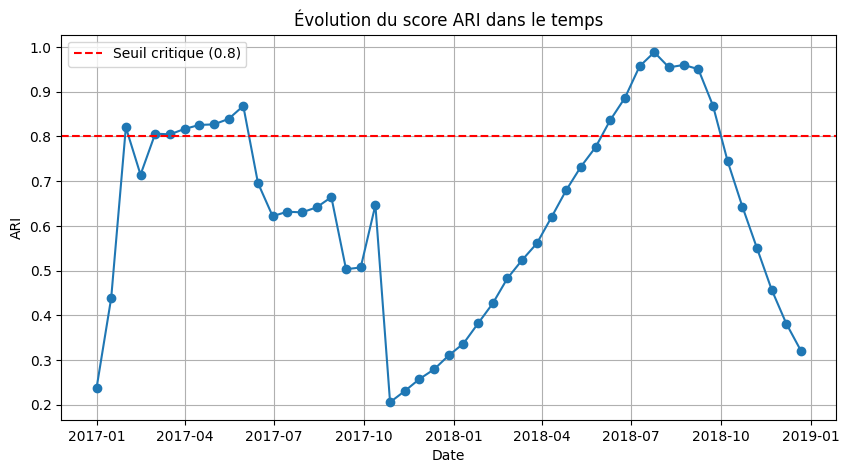

In [100]:

plt.figure(figsize=(10,5))
plt.plot(df_ari["date"], df_ari["ARI"], marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="Seuil critique (0.8)")
plt.title("Évolution du score ARI dans le temps")
plt.xlabel("Date")
plt.ylabel("ARI")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
# Dates problématiques où ARI < SEUIL
SEUIL = 0.8  # Si ARI < 0.8, on considère un réentraînement

if 'df_ari' in globals() and not df_ari.empty:
    dates_problematiques = [row['date'] for _, row in df_ari.iterrows() if row['ARI'] < SEUIL]
    print(f"Il y a {len(dates_problematiques)} dates où l'ARI est < {SEUIL}")
    print("\nPremières dates problématiques:")
    for date in dates_problematiques[:10]:
        print(f"  - {pd.to_datetime(date).date()}")
else:
    print("df_ari indisponible. Exécutez d'abord le calcul de df_ari.")


Il y a 33 dates où l'ARI est < 0.8

Premières dates problématiques:
  - 2017-01-01
  - 2017-01-16
  - 2017-02-15
  - 2017-06-15
  - 2017-06-30
  - 2017-07-15
  - 2017-07-30
  - 2017-08-14
  - 2017-08-29
  - 2017-09-13


In [102]:
threshold = 0.8
stable_periods = df_ari[df_ari["ARI"] >= threshold]
unstable_periods = df_ari[df_ari["ARI"] < threshold]

print(f"Nombre de périodes stables (ARI ≥ {threshold}) : {len(stable_periods)} / {len(df_ari)}")
print(f"Périodes instables détectées : {len(unstable_periods)}")
if len(stable_periods) > 0:
    print("Dernière période stable :", stable_periods["date"].max().strftime("%Y-%m-%d"))

Nombre de périodes stables (ARI ≥ 0.8) : 16 / 49
Périodes instables détectées : 33
Dernière période stable : 2018-09-23


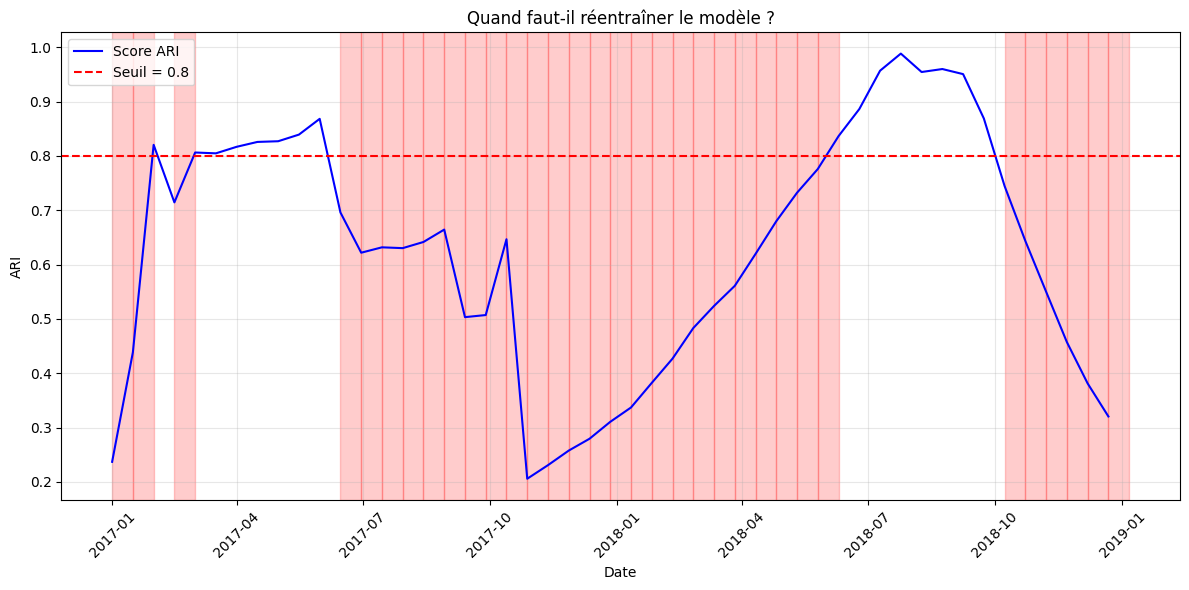

In [103]:
# GRAPHIQUE SIMPLE avec zones rouges
plt.figure(figsize=(12, 6))

# Tracer la courbe ARI
plt.plot(df_ari['date'], df_ari['ARI'], 'b-', label='Score ARI')

# Ligne rouge du seuil
plt.axhline(y=SEUIL, color='red', linestyle='--', label=f'Seuil = {SEUIL}')

# Colorier en rouge quand c'est sous le seuil
for i, row in df_ari.iterrows():
    if row['ARI'] < SEUIL:
        plt.axvspan(row['date'], row['date'] + pd.Timedelta(days=15), 
                    color='red', alpha=0.2)

plt.xlabel('Date')
plt.ylabel('ARI')
plt.title('Quand faut-il réentraîner le modèle ?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On observe que le modèle initial perd de la cohérence après environ 6 mois.


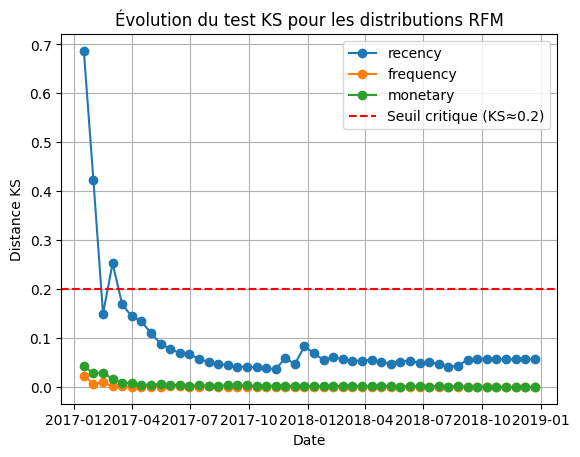

In [104]:


for col in ["recency", "frequency", "monetary"]:
    ks_scores = []
    for i in range(1, len(rfm_snapshots)):
        prev = rfm_snapshots[i-1][col].dropna()
        curr = rfm_snapshots[i][col].dropna()
        if len(prev) > 10 and len(curr) > 10:
            ks_stat, p_value = ks_2samp(prev, curr)
            ks_scores.append((rfm_snapshots[i]['snapshot_date'].iloc[0], ks_stat, p_value))
    ks_df = pd.DataFrame(ks_scores, columns=["date", "KS_stat", "p_value"])
    plt.plot(ks_df["date"], ks_df["KS_stat"], marker='o', label=col)

plt.axhline(0.2, color='red', linestyle='--', label='Seuil critique (KS≈0.2)')
plt.title("Évolution du test KS pour les distributions RFM")
plt.xlabel("Date")
plt.ylabel("Distance KS")
plt.legend()
plt.grid(True)
plt.show()
#les variables F et M sont stables

Automatisation du suivi du score ARI pour déclencher un nouvel entraînement

In [105]:
# détecter les dates où ARI < 0.8  
# Un suivi automatisé du score ARI permettra de déclencher un réentraînement dès que le score passe sous 0.8.
threshold = 0.8
retrain_dates = df_ari.loc[df_ari["ARI"] < threshold, "date"]

print("Réentraînements recommandés aux dates suivantes :")
print(retrain_dates.dt.strftime("%Y-%m-%d").unique())


Réentraînements recommandés aux dates suivantes :
['2017-01-01' '2017-01-16' '2017-02-15' '2017-06-15' '2017-06-30'
 '2017-07-15' '2017-07-30' '2017-08-14' '2017-08-29' '2017-09-13'
 '2017-09-28' '2017-10-13' '2017-10-28' '2017-11-12' '2017-11-27'
 '2017-12-12' '2017-12-27' '2018-01-11' '2018-01-26' '2018-02-10'
 '2018-02-25' '2018-03-12' '2018-03-27' '2018-04-11' '2018-04-26'
 '2018-05-11' '2018-05-26' '2018-10-08' '2018-10-23' '2018-11-07'
 '2018-11-22' '2018-12-07' '2018-12-22']
